# From Darcy to Buckingham — Part 2: Unsaturated Flow

**MOOC "The Hydrology of Soil" — Chapter 3 (second half)**

---

Part 1 ended with **Darcy's law** for *saturated* flow: $q = -K_s\,\nabla h$,
with $K_s$ a constant. But most soil, most of the time, is **unsaturated** —
its pores are only partly water-filled. Edgar **Buckingham (1907)** made the
decisive extension:

$$q \;=\; -K(\psi)\,\nabla h,$$

where the conductivity is **no longer a constant** but a steeply varying
function of the pressure head $\psi$ (equivalently, of the water content
$\theta$). That single change — $K_s \to K(\psi)$ — is the whole content of
"from Darcy to Buckingham".

This notebook lets students:

1. explore the three standard **soil water retention curves** —
   van Genuchten, Brooks–Corey, Kosugi — and see how their parameters reshape
   the curve;
2. apply the **Mualem** model to turn each retention curve into an unsaturated
   conductivity curve $K(\theta)$;
3. see *why* $K$ collapses by many orders of magnitude as the soil dries — the
   physical heart of the Buckingham step.

Run the cells in order (Shift+Enter). Uses NumPy and SciPy.


## 0 — Setup

Run this cell after installing/updating the `soil_course` package.

In [1]:
try:
    from soil_course import *
    print("soil_course already available")
except ModuleNotFoundError:
    !pip install git+https://github.com/panzerotto/soil_course.git
    from soil_course import *

print("Setup complete")


  Cloning https://github.com/panzerotto/soil_course.git to /tmp/pip-req-build-4xp5txnz
  Running command git clone --filter=blob:none --quiet https://github.com/panzerotto/soil_course.git /tmp/pip-req-build-4xp5txnz
  Resolved https://github.com/panzerotto/soil_course.git to commit 99dc881079b17063370d76a60a9b73cc216a2ffa
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for soil-course: filename=soil_course-0.1.0-py3-none-any.whl size=18964 sha256=cef8ae567b496df2cd83a48b84b4d791e4763993b67c1a6db4655d4b36083d32
  Stored in directory: /tmp/pip-ephem-wheel-cache-05ckrngy/wheels/d1/cc/3a/6e11e3051820dbb8642dabb07e7fbe97d50387e4b7f07545bd
Successfully built soil-course
Setup complete


## 1 — Three retention curves

The **soil water retention curve (SWRC)** relates water content $\theta$ to
suction $|\psi|$. We work with the **effective saturation**

$$S_e \;=\; \frac{\theta-\theta_r}{\theta_s-\theta_r}\in[0,1].$$

Three parameterisations are standard. With suction $h = |\psi|$:

**van Genuchten (1980)**
$$S_e(h) = \big[\,1+(\alpha h)^{n}\,\big]^{-m},\qquad m = 1-1/n.$$

**Brooks–Corey (1964)**
$$S_e(h) = (h_b/h)^{\lambda}\ \text{for } h\ge h_b,\quad S_e=1\ \text{otherwise}.$$

**Kosugi (1996)** — assumes a lognormal pore-size distribution
$$S_e(h) = \tfrac12\,\operatorname{erfc}\!\Big[\frac{\ln(h/h_m)}{\sigma\sqrt2}\Big].$$


In [2]:
# The three SWRC model functions and parameter tables are hidden in the package.
# Use these functions directly if you want to inspect values:
# swrc_van_genuchten(...), swrc_brooks_corey(...), swrc_kosugi(...)

print('parameter sets loaded for sand / silt / clay.')

parameter sets loaded for sand / silt / clay.


### 1.1 — Comparing the three curves

The cell below draws all three retention models for a chosen texture on the
same axes. They are different mathematical forms fitted to the same physical
object, so they broadly agree — but differ in detail, especially near
saturation (Brooks–Corey has a sharp **air-entry** corner; the other two are
smooth).


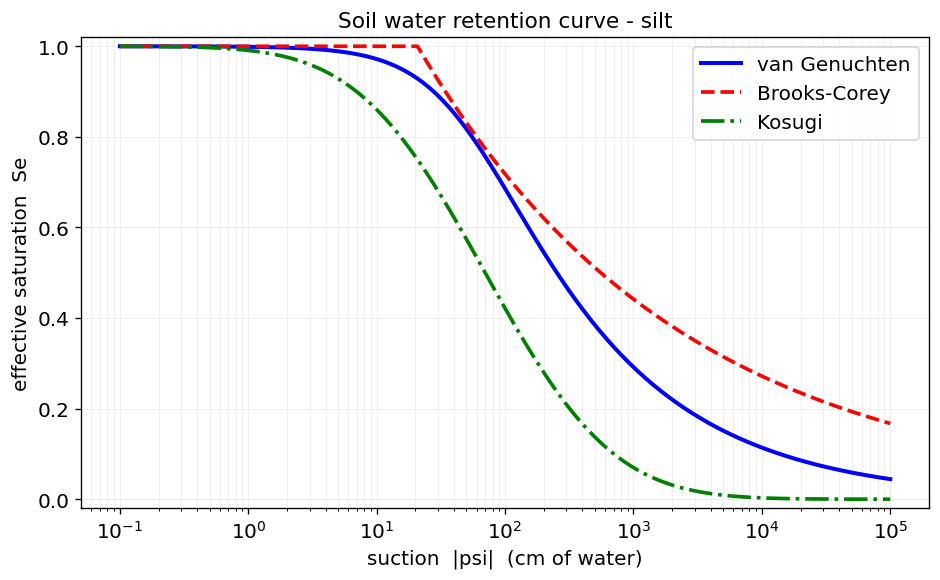

In [3]:
plot_swrc_model_comparison("silt")

## 2 — Interactive: shape the retention curve

Pick a model and move its parameters. Watch how each parameter reshapes the
curve:

* **van Genuchten** — `alpha` slides the curve along the suction axis (it is
  roughly the inverse air-entry head); `n` controls the steepness.
* **Brooks–Corey** — `hb` is the air-entry head (the corner); `lambda` is the
  pore-size distribution index.
* **Kosugi** — `hm` is the median capillary head; `sigma` is the spread of the
  (lognormal) pore-size distribution.

> The slider logic is hidden inside the package. If sliders are not available, use `plot_single_swrc(...)` directly.


In [4]:
interactive_swrc_shape()

## 3 — The Mualem step: from retention curve to conductivity

Buckingham said $K = K(\psi)$, but did not say what the function *is*.
**Mualem (1976)** supplied it: he modelled the pore space as a bundle of
capillaries and derived $K$ from the retention curve itself,

$$K_r(S_e) \;=\; S_e^{\,1/2}
   \left[\frac{\displaystyle\int_0^{S_e} \frac{dS}{h(S)}}
              {\displaystyle\int_0^{1} \frac{dS}{h(S)}}\right]^{2},$$

where $K_r = K/K_s$ is the **relative conductivity** and the $S_e^{1/2}$ factor
encodes tortuosity. Combined with each SWRC this gives a closed form:

**Mualem–van Genuchten**
$$K_r(S_e) = S_e^{1/2}\,\big[\,1-(1-S_e^{1/m})^{m}\,\big]^{2}.$$

**Mualem–Brooks–Corey**
$$K_r(S_e) = S_e^{\,2/\lambda\,+\,5/2}.$$

**Mualem–Kosugi**
$$K_r(S_e) = S_e^{1/2}\,\big[\,Q\!\big(Q^{-1}(S_e)+\sigma\big)\,\big]^{2},$$
where $Q$ is the standard-normal survival function. This is the
**sign-corrected** Kosugi–Mualem result (the sign in the 1996 paper is a known
typo); it satisfies $K_r(1)=1$ exactly.


In [5]:
# The Mualem conductivity formulae are hidden in the package.
# This quick check confirms that the functions behave as expected.

check_mualem_conductivity()

M-vG:  Kr(Se=1.0) = 1.0000    Kr(Se=0.2) = 1.826e-04
M-BC:  Kr(Se=1.0) = 1.0000    Kr(Se=0.2) = 2.862e-05
M-Ko:  Kr(Se=1.0) = 1.0000    Kr(Se=0.2) = 4.122e-05


### 3.1 — Relative conductivity for the three models

For a chosen texture, the cell below plots $K_r(S_e)$ from all three
Mualem-based models. The striking feature is the **steepness**: as the soil
desaturates, $K_r$ falls by many orders of magnitude — this is the curve that
makes unsaturated flow so different from the saturated Darcy picture.


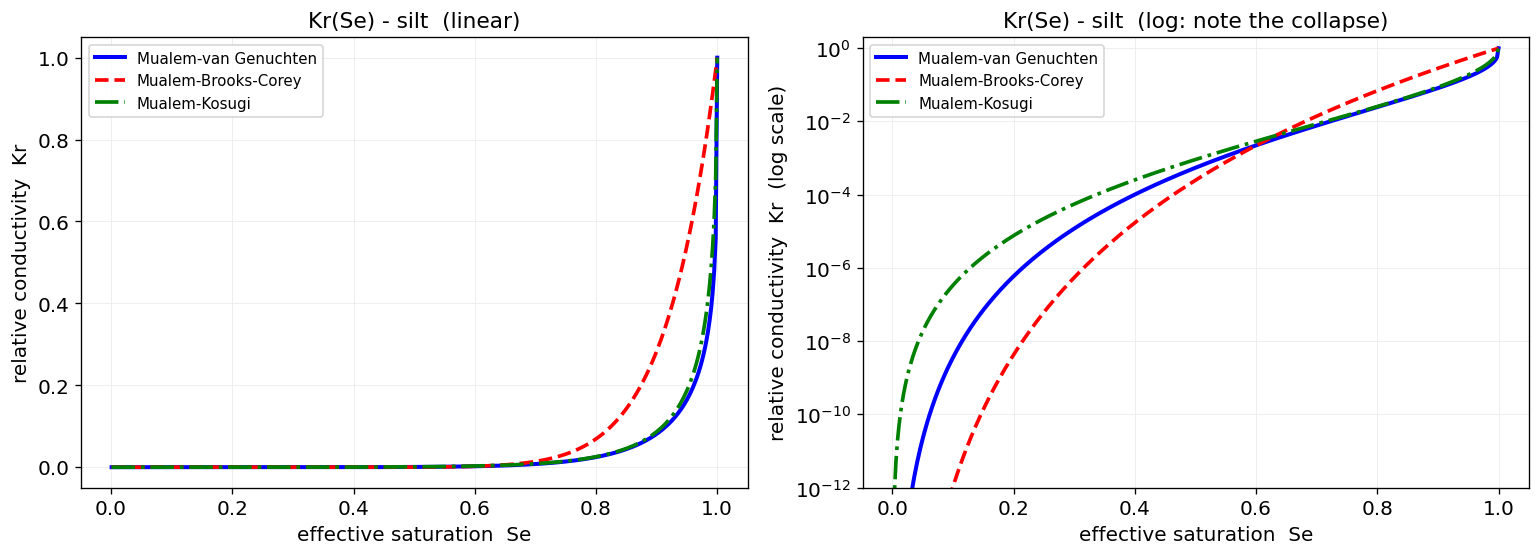

In [6]:
plot_Kr_comparison("silt")

The **log panel** is the point of the whole chapter. Between full
saturation and, say, $S_e = 0.2$, the relative conductivity drops by **six to
ten orders of magnitude**. A soil that is only modestly dry is, for practical
purposes, almost impermeable. This is why $K$ *cannot* be treated as a constant
— and why Buckingham's $K(\psi)$, not Darcy's $K_s$, governs the unsaturated
zone.


## 4 — The full picture: K as a function of suction

Putting Sections 1 and 3 together: chain the retention curve $S_e(\psi)$ with
the Mualem conductivity $K_r(S_e)$ to get $K$ directly as a function of suction,
$K(\psi) = K_s\,K_r(S_e(\psi))$ — the Buckingham conductivity in the form a
modeller actually uses.


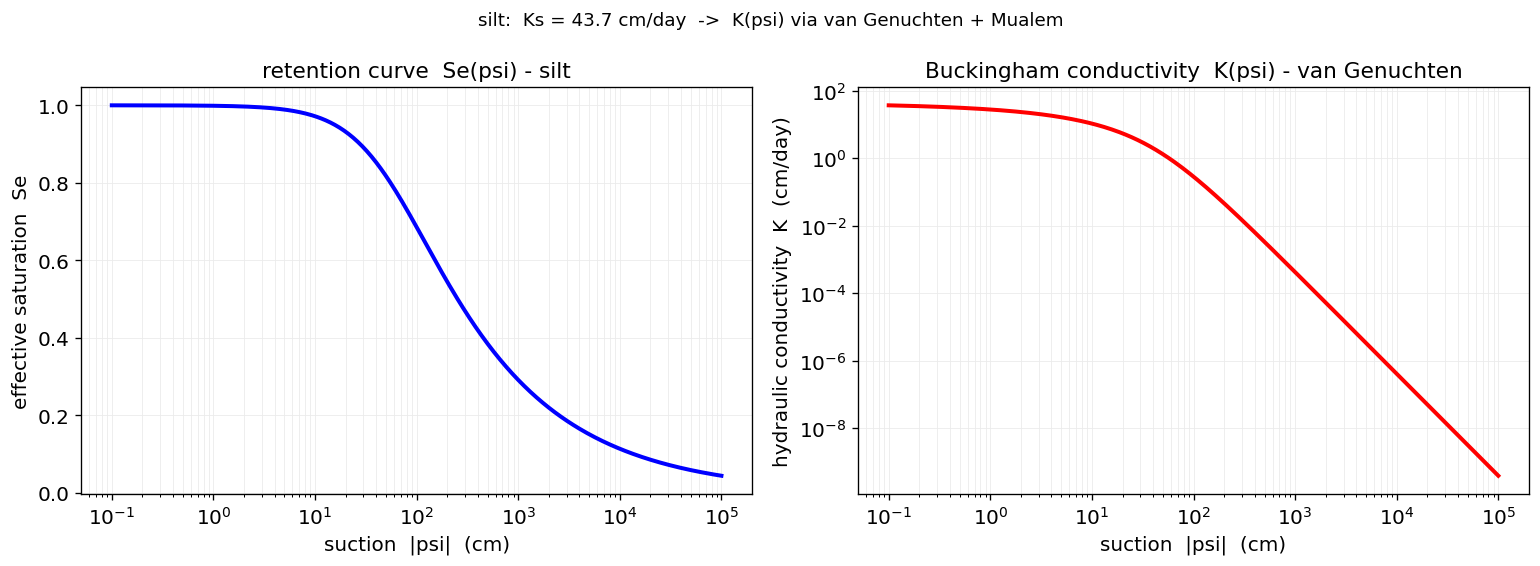

In [7]:
plot_K_of_psi("silt", "van Genuchten")

In [8]:
interactive_K_of_psi()

## Exercises

1. **Air entry.** In Section 2, choose Brooks–Corey and increase `hb`. The
   curve develops a flat shelf near saturation. What does that shelf mean
   physically, and why do van Genuchten and Kosugi not have a sharp version of
   it?

2. **From curve to conductivity.** For a silt, read off the suction at which
   $S_e = 0.5$ (Section 1). Then, from the $K(\psi)$ plot of Section 4, read
   $K$ at that same suction. By what factor has $K$ fallen from $K_s$?

3. **Texture and steepness.** Plot $K_r(S_e)$ (Section 3) for sand and then for
   clay. Which dries to near-zero conductivity *faster* in terms of $S_e$?
   Relate your answer to the pore-size distribution of each soil.

4. **The three models disagree most where?** Overlay the three retention curves
   (Section 1) for clay. At which suctions do they agree well, and where do
   they diverge? Which region matters most for plant-available water?

5. **Why Buckingham, not Darcy.** In two or three sentences, explain to a
   fellow student why the single replacement $K_s \to K(\psi)$ is enough to
   make unsaturated flow qualitatively different from saturated Darcy flow —
   and why it makes Richards' equation (Chapter 4) nonlinear.

---

*Companion to the MOOC "The Hydrology of Soil", Chapter 3 (Part 2) —
unsaturated flow, retention curves and Mualem conductivity. The Mualem-Kosugi
expression uses the corrected +sigma/sqrt(2) sign. Licensed CC BY-SA,
consistent with the lecture slides.*
